# PHQ-8 Depression Detection — Simple CNN (Regression)

**Architecture**: 2 convolutional blocks (Conv2D → BatchNorm → ReLU → MaxPool), adaptive average pooling, lightweight FC head.

**Motivation**: The 3-block CNN (~634K params) overfits immediately — dev MSE diverges from epoch 1. This notebook uses a much smaller model (~38K params) to reduce overfitting.

**Input**: log-mel spectrograms `(1, 128, 801)` saved as `.npy` files.

**Target**: PHQ-8 score (continuous, 0–24).

## 1. Imports & Configuration

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam

import matplotlib.pyplot as plt
from scipy.stats import pearsonr

In [3]:
# Paths
BASE_DIR = Path("..") 
PROCESSED_DIR = BASE_DIR / "processed"
META_CSV = PROCESSED_DIR / "segment_metadata.csv"
SPEC_ROOT = PROCESSED_DIR / "spectrograms"
SAVE_DIR = BASE_DIR / "experiments" / "best_model" / "simple_cnn"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Training hyper-parameters
BATCH_SIZE = 64
NUM_EPOCHS = 100
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-3
CHECKPOINT_FREQ = 10
EARLY_STOPPING_PATIENCE = 10
NUM_WORKERS = 0

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if DEVICE.type == "cpu":
    print("  WARNING: No GPU detected — training will be significantly slower.")
print(f"Checkpoints will be saved to: {SAVE_DIR.resolve()}")

Using device: cuda
Checkpoints will be saved to: C:\Users\edgar\OneDrive\Documents\Term_8\Deep_learning\Project\phq8_depression_detection\experiments\best_model\simple_cnn


## 2. Dataset

In [4]:
def spec_augment(spec, n_freq_masks=2, freq_mask_width=10, n_time_masks=2, time_mask_width=50):
    """
    SpecAugment: randomly zero-out horizontal (frequency) and vertical (time)
    bands of a spectrogram.  Applied in-place on a (n_mels, n_frames) tensor.
    """
    n_mels, n_frames = spec.shape
    for _ in range(n_freq_masks):
        f = torch.randint(0, freq_mask_width + 1, (1,)).item()
        f0 = torch.randint(0, max(n_mels - f, 1), (1,)).item()
        spec[f0 : f0 + f, :] = 0.0
    for _ in range(n_time_masks):
        t = torch.randint(0, time_mask_width + 1, (1,)).item()
        t0 = torch.randint(0, max(n_frames - t, 1), (1,)).item()
        spec[:, t0 : t0 + t] = 0.0
    return spec

class SpectrogramDataset(Dataset):
    def __init__(self, meta_df: pd.DataFrame, spec_root: Path, split: str):
        self.meta = meta_df.reset_index(drop=True)
        self.split_dir = spec_root / split
        self.augment = (split == "train")

    def __len__(self):
        return len(self.meta)

    def __getitem__(self, idx):
        row = self.meta.iloc[idx]
        pid = int(row["participant_id"])
        seg = int(row["segment_idx"])
        spec_path = self.split_dir / f"{pid}_seg{seg:04d}.npy"
        spec = np.load(spec_path).astype(np.float32)
        spec = torch.from_numpy(spec)                        # (128, n_frames)
        if self.augment:
            spec = spec_augment(spec)
        spec = spec.unsqueeze(0)                             # (1, 128, n_frames)
        label = torch.tensor(float(row["phq_score"]), dtype=torch.float32)
        pid_t = torch.tensor(pid, dtype=torch.long)
        return spec, label, pid_t                           # pid needed for participant-level aggregation

def build_loaders(meta_csv, spec_root, batch_size, num_workers):
    meta = pd.read_csv(meta_csv)
    splits = {}
    for split in ("train", "dev", "test"):
        df = meta[meta["split"] == split].reset_index(drop=True)
        ds = SpectrogramDataset(df, spec_root, split)
        splits[split] = DataLoader(
            ds, batch_size=batch_size, shuffle=(split == "train"),
            num_workers=num_workers, pin_memory=True
        )
        display_name = "validation" if split == "dev" else split
        aug_str = " + SpecAugment" if ds.augment else ""
        print(f"  {display_name:10s}: {len(df):6,} segments{aug_str}  →  {ds.split_dir}")
    return splits

print("Building data loaders…")
loaders      = build_loaders(META_CSV, SPEC_ROOT, BATCH_SIZE, NUM_WORKERS)
train_loader = loaders["train"]
val_loader   = loaders["dev"]
test_loader  = loaders["test"]

Building data loaders…
  train     : 11,362 segments + SpecAugment  →  ..\processed\spectrograms\train
  validation:  4,322 segments  →  ..\processed\spectrograms\dev
  test      :  5,904 segments  →  ..\processed\spectrograms\test


## 3. Model — Simple CNN Regression

In [5]:
class SimpleCNNRegressor(nn.Module):
    """
    Lightweight 2-block CNN for PHQ-8 regression.

    Input  : (B, 1, 128, 801)  — log-mel spectrogram
    Output : (B,)              — predicted PHQ-8 score
    """

    def __init__(self, dropout: float = 0.5):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 16, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                    # → (16, 64, 400)
            # Block 2
            nn.Conv2d(16, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                    # → (32, 32, 200)
        )

        self.pool = nn.AdaptiveAvgPool2d((4, 4))   # → (32, 4, 4) = 512

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 4 * 4, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.head(x)
        return x.squeeze(1)

model = SimpleCNNRegressor(dropout=0.5).to(DEVICE)

with torch.no_grad():
    dummy = torch.zeros(2, 1, 128, 801, device=DEVICE)
    out   = model(dummy)
    print(f"Output shape: {out.shape}  (expected: (2,))")

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

Output shape: torch.Size([2])  (expected: (2,))
Trainable parameters: 37,745


## 4. Training Loop

In [6]:
criterion = nn.MSELoss()
optimizer = Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

history = {"train_loss": [], "val_loss": [], "val_rmse": []}
best_val_loss = float("inf")
epochs_no_improve = 0

def train_epoch(loader):
    """Segment-level training pass."""
    model.train()
    total_loss, total_samples = 0.0, 0
    for specs, labels, _ in loader:
        specs  = specs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        optimizer.zero_grad()
        preds  = model(specs)
        loss   = criterion(preds, labels)
        loss.backward()
        optimizer.step()
        total_loss    += loss.item() * len(labels)
        total_samples += len(labels)
    return total_loss / total_samples

def evaluate_participant(loader):
    """
    Participant-level evaluation.
    Runs inference on every segment, then averages each participant's
    segment predictions into one score before computing metrics.
    """
    model.eval()
    records = []
    with torch.no_grad():
        for specs, labels, pids in loader:
            specs = specs.to(DEVICE, non_blocking=True)
            preds = model(specs).cpu().numpy()
            for pid, pred, label in zip(pids.numpy(), preds, labels.numpy()):
                records.append((int(pid), float(pred), float(label)))

    df = pd.DataFrame(records, columns=["participant_id", "pred", "label"])
    agg = df.groupby("participant_id").agg(
        pred  = ("pred",  "mean"),
        label = ("label", "first"),
    ).reset_index()

    mse  = float(np.mean((agg["pred"].values - agg["label"].values) ** 2))
    rmse = mse ** 0.5
    return mse, rmse, agg

for epoch in range(1, NUM_EPOCHS + 1):

    train_mse = train_epoch(train_loader)
    val_mse, val_rmse, _ = evaluate_participant(val_loader)

    history["train_loss"].append(train_mse)
    history["val_loss"].append(val_mse)
    history["val_rmse"].append(val_rmse)

    print(f"Epoch [{epoch}/{NUM_EPOCHS}], Train MSE: {train_mse:.4f}, Val MSE: {val_mse:.4f}, Val RMSE: {val_rmse:.4f}")

    # Checkpoint
    if epoch % CHECKPOINT_FREQ == 0:
        ckpt_path = SAVE_DIR / f"epoch{epoch}_simple_cnn.pth"
        torch.save({
            "epoch":                epoch,
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_mse":            train_mse,
            "val_mse":              val_mse,
        }, ckpt_path)
        print(f"  Checkpoint saved -> {ckpt_path.name}")

    # Save best / early stopping (participant-level val MSE)
    if val_mse < best_val_loss:
        best_val_loss     = val_mse
        epochs_no_improve = 0
        best_path = SAVE_DIR / "simple_cnn_best.pth"
        torch.save({
            "epoch":                epoch,
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_mse":              val_mse,
            "val_rmse":             val_rmse,
        }, best_path)
        print(f"  Best model saved -> {best_path.name}  (val MSE {val_mse:.4f})")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
            print(f"\n  Early stopping triggered — no improvement for {EARLY_STOPPING_PATIENCE} epochs.")
            break

print("\nTraining complete.")
print(f"Best val MSE (participant) : {best_val_loss:.4f}  |  RMSE : {best_val_loss**0.5:.4f}")

Epoch [1/100], Train MSE: 35.3317, Val MSE: 43.9204, Val RMSE: 6.6273
  Best model saved -> simple_cnn_best.pth  (val MSE 43.9204)
Epoch [2/100], Train MSE: 29.5362, Val MSE: 44.6361, Val RMSE: 6.6810
Epoch [3/100], Train MSE: 29.2105, Val MSE: 44.6448, Val RMSE: 6.6817
Epoch [4/100], Train MSE: 29.0061, Val MSE: 44.6399, Val RMSE: 6.6813
Epoch [5/100], Train MSE: 28.9786, Val MSE: 46.1762, Val RMSE: 6.7953
Epoch [6/100], Train MSE: 28.9486, Val MSE: 43.6833, Val RMSE: 6.6093
  Best model saved -> simple_cnn_best.pth  (val MSE 43.6833)
Epoch [7/100], Train MSE: 28.7563, Val MSE: 44.0715, Val RMSE: 6.6386
Epoch [8/100], Train MSE: 28.8556, Val MSE: 45.1708, Val RMSE: 6.7209
Epoch [9/100], Train MSE: 28.5426, Val MSE: 44.1069, Val RMSE: 6.6413
Epoch [10/100], Train MSE: 28.7971, Val MSE: 44.5439, Val RMSE: 6.6741
  Checkpoint saved -> epoch10_simple_cnn.pth
Epoch [11/100], Train MSE: 28.5829, Val MSE: 43.9438, Val RMSE: 6.6290
Epoch [12/100], Train MSE: 28.4698, Val MSE: 43.2935, Val RMS

## 5. Training Curves

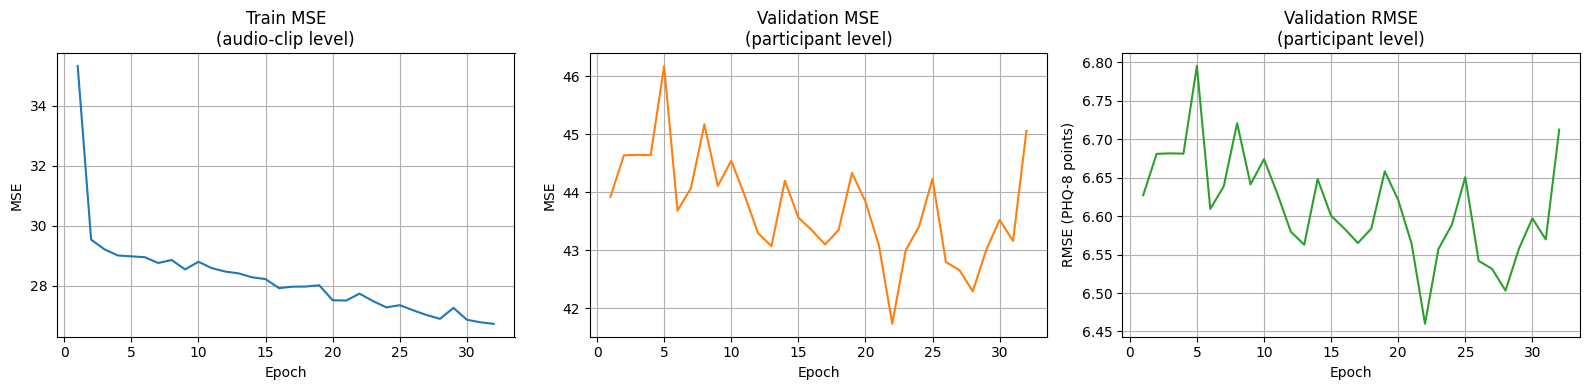

In [7]:
epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(epochs, history["train_loss"], color="tab:blue")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].set_title("Train MSE\n(audio-clip level)")
axes[0].grid(True)

axes[1].plot(epochs, history["val_loss"], color="tab:orange")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE")
axes[1].set_title("Validation MSE\n(participant level)")
axes[1].grid(True)

axes[2].plot(epochs, history["val_rmse"], color="tab:green")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("RMSE (PHQ-8 points)")
axes[2].set_title("Validation RMSE\n(participant level)")
axes[2].grid(True)

plt.tight_layout()
plt.show()

## 6. Evaluation on Test Set

Loads the best checkpoint and reports participant-level MSE, RMSE, MAE, and Pearson r.
Each participant's segment predictions are averaged into a single score before computing metrics.

In [8]:
# Load best weights
best_ckpt = torch.load(SAVE_DIR / "simple_cnn_best.pth", map_location=DEVICE, weights_only=True)
model.load_state_dict(best_ckpt["model_state_dict"])
print(f"Loaded best model from epoch {best_ckpt['epoch']}  "
      f"(val MSE {best_ckpt['val_mse']:.4f})")

# Participant-level predictions on test set
_, _, test_agg = evaluate_participant(test_loader)

all_preds  = test_agg["pred"].values
all_labels = test_agg["label"].values

print(f"  Participants evaluated: {len(test_agg)}")

# Metrics
test_mse  = float(np.mean((all_preds - all_labels) ** 2))
test_rmse = test_mse ** 0.5
test_mae  = float(np.mean(np.abs(all_preds - all_labels)))
test_r, _ = pearsonr(all_preds, all_labels)

print("\n── Test-set results (participant level) ───────────")
print(f"  MSE       : {test_mse:.4f}")
print(f"  RMSE      : {test_rmse:.4f}  PHQ-8 points")
print(f"  MAE       : {test_mae:.4f}  PHQ-8 points")
print(f"  Pearson r : {test_r:.4f}")

Loaded best model from epoch 22  (val MSE 41.7302)
  Participants evaluated: 47

── Test-set results (participant level) ───────────
  MSE       : 41.7172
  RMSE      : 6.4589  PHQ-8 points
  MAE       : 5.4171  PHQ-8 points
  Pearson r : 0.0249


## 7. Prediction Distribution

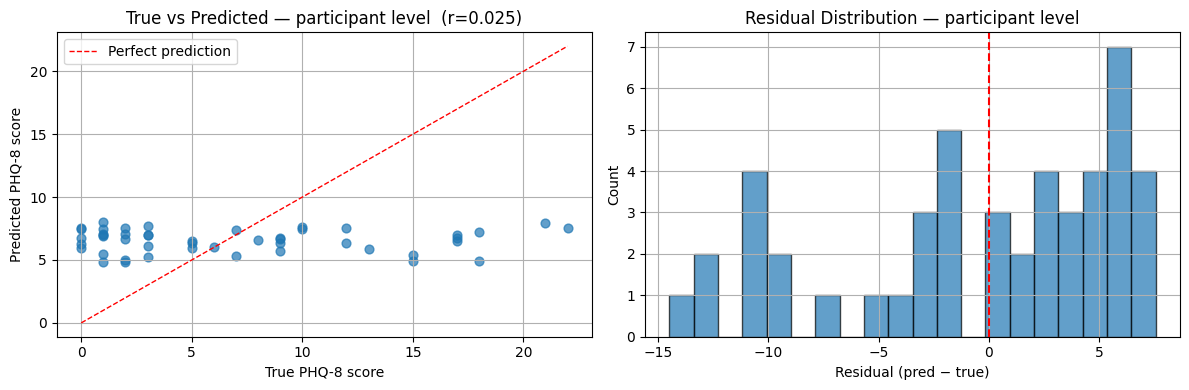

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# One point per participant
axes[0].scatter(all_labels, all_preds, alpha=0.7, s=40)
lo, hi = min(all_labels.min(), all_preds.min()), max(all_labels.max(), all_preds.max())
axes[0].plot([lo, hi], [lo, hi], "r--", linewidth=1, label="Perfect prediction")
axes[0].set_xlabel("True PHQ-8 score")
axes[0].set_ylabel("Predicted PHQ-8 score")
axes[0].set_title(f"True vs Predicted — participant level  (r={test_r:.3f})")
axes[0].legend()
axes[0].grid(True)

residuals = all_preds - all_labels
axes[1].hist(residuals, bins=20, edgecolor="k", alpha=0.7)
axes[1].axvline(0, color="r", linestyle="--")
axes[1].set_xlabel("Residual (pred − true)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution — participant level")
axes[1].grid(True)

plt.tight_layout()
plt.show()